# RoadSafe India — Accident–Fatality Relationship

## Objective

This notebook examines the relationship between reported road accidents and
reported road fatalities across Indian States/UTs in 2024.

The analysis aims to determine whether States/UTs with more reported
accidents generally also have more reported fatalities and to identify
States/UTs that deviate from the overall relationship.

This is a descriptive analysis and does not establish causation.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the previously created fatality-analysis dataset
data_path = (
    "../data/processed/"
    "state_fatality_analysis_2024.csv"
)

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows: 35
Columns: 6


,state,2024_accidents,2024_killed,population_2024,fatalities_per_100k_population,fatalities_per_100_accidents
0,Andhra Pradesh,19557.0,8346,53340000,15.646794,42.675257
1,Arunachal Pradesh,277.0,168,1576000,10.659898,60.649819
2,Assam,7848.0,3351,36047000,9.296197,42.698777
3,Bihar,11610.0,9347,128592000,7.268726,80.508183
4,Chhattisgarh,14857.0,6945,30524000,22.752588,46.745642


In [3]:
relationship_df = df[
    [
        "state",
        "2024_accidents",
        "2024_killed",
        "population_2024",
        "fatalities_per_100k_population",
        "fatalities_per_100_accidents"
    ]
].copy()

display(relationship_df.head())

,state,2024_accidents,2024_killed,population_2024,fatalities_per_100k_population,fatalities_per_100_accidents
0,Andhra Pradesh,19557.0,8346,53340000,15.646794,42.675257
1,Arunachal Pradesh,277.0,168,1576000,10.659898,60.649819
2,Assam,7848.0,3351,36047000,9.296197,42.698777
3,Bihar,11610.0,9347,128592000,7.268726,80.508183
4,Chhattisgarh,14857.0,6945,30524000,22.752588,46.745642


In [4]:
print("Missing values:")
display(relationship_df.isnull().sum())

print("\nDuplicate State/UTs:")
print(relationship_df["state"].duplicated().sum())

print("\nNumber of States/UTs:")
print(relationship_df["state"].nunique())

Missing values:


state                             0
2024_accidents                    0
2024_killed                       0
population_2024                   0
fatalities_per_100k_population    0
fatalities_per_100_accidents      1
dtype: int64


Duplicate State/UTs:
0

Number of States/UTs:
35


In [5]:
correlation = relationship_df[
    [
        "2024_accidents",
        "2024_killed"
    ]
].corr().loc[
    "2024_accidents",
    "2024_killed"
]

print(
    f"Pearson correlation between reported accidents "
    f"and reported fatalities: {correlation:.3f}"
)

Pearson correlation between reported accidents and reported fatalities: 0.861


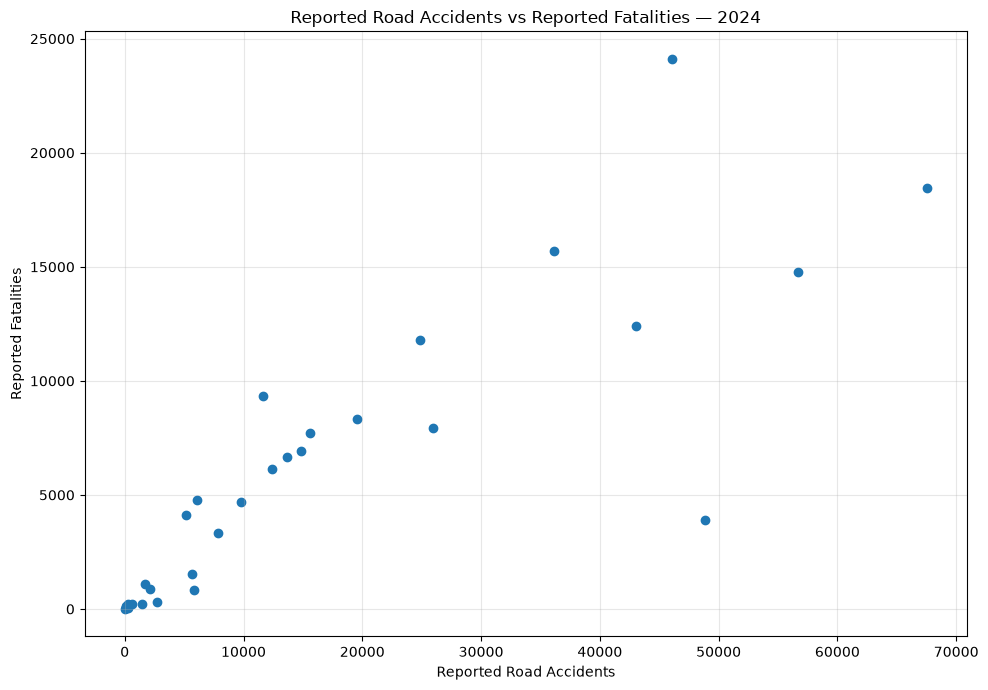

In [6]:
plt.figure(figsize=(10, 7))

plt.scatter(
    relationship_df["2024_accidents"],
    relationship_df["2024_killed"]
)

plt.title(
    "Reported Road Accidents vs Reported Fatalities — 2024"
)

plt.xlabel("Reported Road Accidents")
plt.ylabel("Reported Fatalities")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

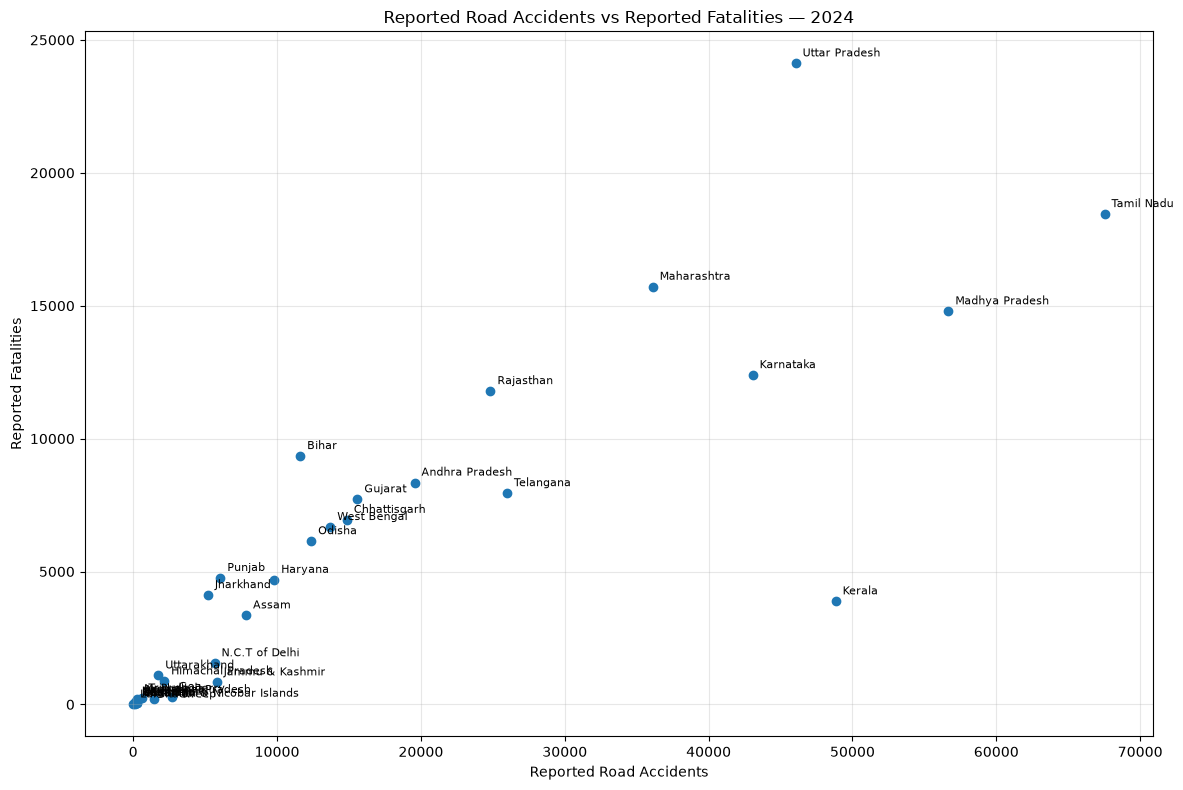

In [7]:
plt.figure(figsize=(12, 8))

plt.scatter(
    relationship_df["2024_accidents"],
    relationship_df["2024_killed"]
)

for _, row in relationship_df.iterrows():
    plt.annotate(
        row["state"],
        (
            row["2024_accidents"],
            row["2024_killed"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title(
    "Reported Road Accidents vs Reported Fatalities — 2024"
)

plt.xlabel("Reported Road Accidents")
plt.ylabel("Reported Fatalities")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
x = relationship_df["2024_accidents"]
y = relationship_df["2024_killed"]

slope, intercept = np.polyfit(x, y, 1)

relationship_df["expected_fatalities"] = (
    slope * relationship_df["2024_accidents"]
    + intercept
)

relationship_df["fatality_residual"] = (
    relationship_df["2024_killed"]
    - relationship_df["expected_fatalities"]
)

print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.2f}")

Slope: 0.287292
Intercept: 1057.41


In [10]:
high_residuals = (
    relationship_df
    .sort_values(
        "fatality_residual",
        ascending=False
    )
)

print(
    "States/UTs with the largest positive "
    "fatality residuals:"
)

display(
    high_residuals[
        [
            "state",
            "2024_accidents",
            "2024_killed",
            "expected_fatalities",
            "fatality_residual"
        ]
    ].head(10)
)

States/UTs with the largest positive fatality residuals:


,state,2024_accidents,2024_killed,expected_fatalities,fatality_residual
26,Uttar Pradesh,46052.0,24118,14287.776763,9830.223237
3,Bihar,11610.0,9347,4392.870407,4954.129593
13,Maharashtra,36118.0,15715,11433.819393,4281.180607
20,Rajasthan,24838.0,11790,8193.167175,3596.832825
6,Gujarat,15588.0,7717,5535.717439,2181.282561
19,Punjab,6063.0,4759,2799.262441,1959.737559
27,West Bengal,13702.0,6676,4993.884985,1682.115015
0,Andhra Pradesh,19557.0,8346,6675.978845,1670.021155
4,Chhattisgarh,14857.0,6945,5325.707087,1619.292913
9,Jharkhand,5196.0,4114,2550.180395,1563.819605


In [11]:
low_residuals = (
    relationship_df
    .sort_values(
        "fatality_residual",
        ascending=True
    )
)

print(
    "States/UTs with the largest negative "
    "fatality residuals:"
)

display(
    low_residuals[
        [
            "state",
            "2024_accidents",
            "2024_killed",
            "expected_fatalities",
            "fatality_residual"
        ]
    ].head(10)
)

States/UTs with the largest negative fatality residuals:


,state,2024_accidents,2024_killed,expected_fatalities,fatality_residual
11,Kerala,48834.0,3880,15087.022727,-11207.022727
12,Madhya Pradesh,56669.0,14791,17337.954476,-2546.954476
22,Tamil Nadu,67526.0,18449,20457.082236,-2008.082236
31,Jammu & Kashmir,5808.0,831,2726.003016,-1895.003016
5,Goa,2682.0,286,1827.928651,-1541.928651
34,Puducherry,1431.0,218,1468.526530,-1250.526530
30,N.C.T of Delhi,5657.0,1551,2682.621944,-1131.621944
32,Ladakh,264.0,61,1133.256926,-1072.256926
14,Manipur,299.0,72,1143.312141,-1071.312141
28,Andaman & Nicobar Islands,135.0,29,1096.196275,-1067.196275


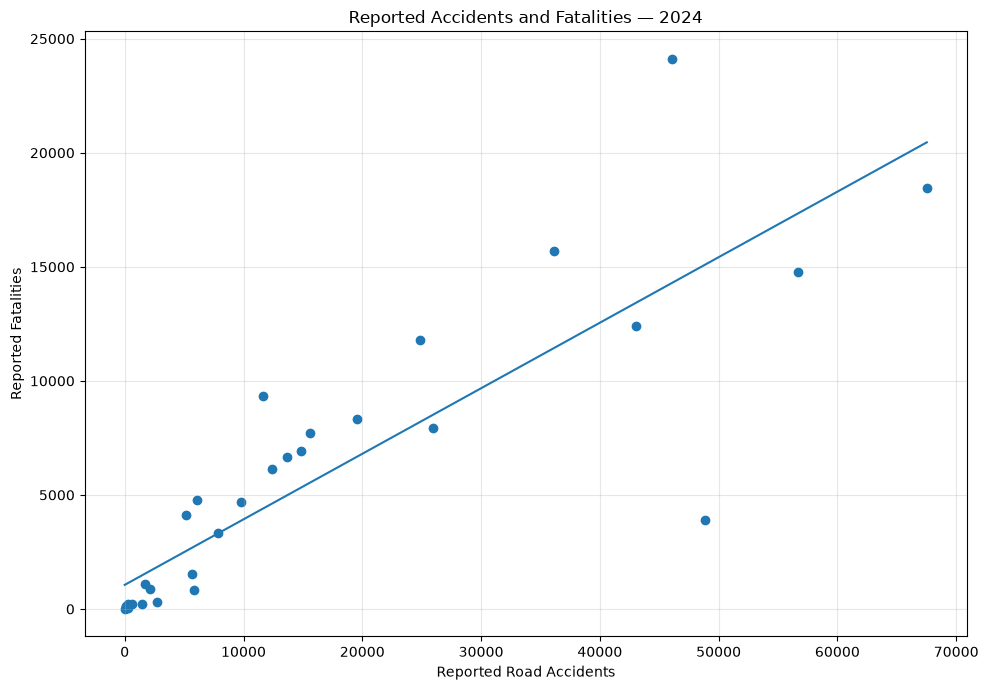

In [12]:
plt.figure(figsize=(10, 7))

plt.scatter(
    relationship_df["2024_accidents"],
    relationship_df["2024_killed"]
)

x_values = np.linspace(
    relationship_df["2024_accidents"].min(),
    relationship_df["2024_accidents"].max(),
    100
)

y_values = (
    slope * x_values
    + intercept
)

plt.plot(
    x_values,
    y_values
)

plt.title(
    "Reported Accidents and Fatalities — 2024"
)

plt.xlabel("Reported Road Accidents")
plt.ylabel("Reported Fatalities")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
severity_ranking = (
    relationship_df
    .sort_values(
        "fatalities_per_100_accidents",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    severity_ranking[
        [
            "state",
            "2024_accidents",
            "2024_killed",
            "fatalities_per_100_accidents"
        ]
    ].head(15)
)

,state,2024_accidents,2024_killed,fatalities_per_100_accidents
0,Mizoram,118.0,110,93.220339
1,Bihar,11610.0,9347,80.508183
2,Jharkhand,5196.0,4114,79.176289
3,Punjab,6063.0,4759,78.492495
4,Meghalaya,269.0,197,73.234201
5,Uttarakhand,1747.0,1090,62.392673
6,Arunachal Pradesh,277.0,168,60.649819
7,Uttar Pradesh,46052.0,24118,52.371233
8,Odisha,12375.0,6142,49.632323
9,Gujarat,15588.0,7717,49.506030


In [14]:
comparison_table = relationship_df[
    [
        "state",
        "2024_accidents",
        "2024_killed",
        "fatalities_per_100k_population",
        "fatalities_per_100_accidents",
        "fatality_residual"
    ]
].copy()

display(
    comparison_table.sort_values(
        "2024_killed",
        ascending=False
    ).head(15)
)

,state,2024_accidents,2024_killed,fatalities_per_100k_population,fatalities_per_100_accidents,fatality_residual
26,Uttar Pradesh,46052.0,24118,10.130293,52.371233,9830.223237
22,Tamil Nadu,67526.0,18449,23.932079,27.321328,-2008.082236
13,Maharashtra,36118.0,15715,12.339039,43.510161,4281.180607
12,Madhya Pradesh,56669.0,14791,16.882776,26.100690,-2546.954476
10,Karnataka,43062.0,12390,18.189826,28.772468,-1038.774092
20,Rajasthan,24838.0,11790,14.396132,47.467590,3596.832825
3,Bihar,11610.0,9347,7.268726,80.508183,4954.129593
0,Andhra Pradesh,19557.0,8346,15.646794,42.675257,1670.021155
23,Telangana,25986.0,7949,20.769753,30.589548,-573.978234
6,Gujarat,15588.0,7717,10.663700,49.506030,2181.282561


In [15]:
output_path = (
    "../data/processed/"
    "accident_fatality_relationship_2024.csv"
)

relationship_df.to_csv(
    output_path,
    index=False
)

print("Relationship analysis dataset saved:")
print(output_path)

Relationship analysis dataset saved:
../data/processed/accident_fatality_relationship_2024.csv


In [16]:
verification_df = pd.read_csv(output_path)

print("Verification successful.")
print(f"Rows: {verification_df.shape[0]}")
print(f"Columns: {verification_df.shape[1]}")

display(verification_df.head())

Verification successful.
Rows: 35
Columns: 8


,state,2024_accidents,2024_killed,population_2024,fatalities_per_100k_population,fatalities_per_100_accidents,expected_fatalities,fatality_residual
0,Andhra Pradesh,19557.0,8346,53340000,15.646794,42.675257,6675.978845,1670.021155
1,Arunachal Pradesh,277.0,168,1576000,10.659898,60.649819,1136.991720,-968.991720
2,Assam,7848.0,3351,36047000,9.296197,42.698777,3312.078417,38.921583
3,Bihar,11610.0,9347,128592000,7.268726,80.508183,4392.870407,4954.129593
4,Chhattisgarh,14857.0,6945,30524000,22.752588,46.745642,5325.707087,1619.292913


## Initial Findings

The accident–fatality analysis examines whether States/UTs with more reported
road accidents also tend to have more reported fatalities.

The correlation between reported accidents and reported fatalities provides
a summary measure of their linear association.

The scatter plot helps identify States/UTs that differ from the overall
pattern.

The residual analysis provides a descriptive indication of States/UTs whose
fatality counts are relatively higher or lower than expected from the simple
accident-count relationship.

These results should not be interpreted causally. Differences may reflect
population, traffic exposure, road characteristics, reporting practices,
accident composition and other factors that are not represented in the
current dataset.

## Key Findings

The Pearson correlation between reported road accidents and reported
fatalities across States/UTs in 2024 is approximately 0.861, indicating a
strong positive linear association.

This means that States/UTs with higher reported accident counts generally
also tend to have higher reported fatality counts.

However, the correlation does not establish causation. Population size,
traffic exposure, road characteristics, reporting practices and other
variables may influence both accident and fatality counts.

The residual analysis identifies States/UTs whose observed fatality counts
are substantially higher or lower than expected from the simple linear
relationship between reported accidents and fatalities.

Uttar Pradesh has the largest positive residual in this analysis, indicating
that its reported fatality count is substantially higher than the value
predicted by the simple accident-count relationship.

These residuals should be treated as signals for further investigation,
not as causal explanations.